##Contexte

- Notre projet est en format vidéo et images.
- La variable cible est 11 catégories d'obstacles. (4 maintenant)
- La métrique utilisé est mAP (mean Average Precision). Combine (Précision + Rappel)

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Importation de bibliotheque necessaire
import pandas as pd
import numpy as np
import torch
import os
import cv2
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import shutil
from PIL import Image

In [ ]:
torch.cuda.empty_cache()
gc.collect()

0

In [ ]:
# chemin
Drive_path = "/content/drive/MyDrive/Projet Capstone/VideoCap"
Local_data_path = "/content/data"
drive_root_search = f"{Drive_path}/images"
!rm -rf /content/data

In [ ]:
def bbox_to_yolo(x1, y1, x2, y2, img_w=1280, img_h=720):

    width = x2 - x1
    height = y2 - y1

    x_center = x1 + (width / 2)
    y_center = y1 + (height / 2)

    x_c_norm = x_center / img_w
    y_c_norm = y_center /img_h

    w_norm = width / img_w
    h_norm = height / img_h

    return x_c_norm, y_c_norm, w_norm, h_norm

In [ ]:
# 1. NETTOYAGE RADICAL (Correction de la typo exists)
# Création de l'arborescence YOLO plate et propre
for d in ["images/train", "images/test", "labels/train", "labels/test"]:
    path = os.path.join(Local_data_path, d)
    shutil.rmtree(path, ignore_errors=True)
    os.makedirs(path, exist_ok=True)

In [ ]:
print("Indexation du Drive... (cela peut prendre 2-3 minutes)")
#On crée un dictionnaire de toutes les images présentes sur le Drive (nom -> chemin complet)
# C'est beaucoup plus rapide que de faire os.path.exists() en boucle
drive_files_dict = {f: os.path.join(root, f)
                    for root, _, files in os.walk(drive_root_search) # Scan du Drive via 'os.walk' pour créer le dictionnaire de chaque chemins images.
                    for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))}

train_path = os.path.join(Local_data_path, "images/train")
os.makedirs(train_path, exist_ok=True)

print(f"Indexation terminée. {len(drive_files_dict)} images vers {train_path}...")
#print("Liaison initiale vers le dossier train...")
#for name, path in drive_files_dict.items():
 #   dst = os.path.join(train_path, name)
  #  if not os.path.exists(dst):
   #     try:
    #        os.symlink(path, dst)
     #   except Exception as e:
      #      pass
nombre_liens = len(os.listdir(train_path))
print(f"Succès ! {nombre_liens} liens créés sans erreurs.")

Indexation du Drive... (cela peut prendre 2-3 minutes)
Indexation terminée. 2047 images vers /content/data/images/train...
Succès ! 0 liens créés sans erreurs.


La prochaine cellule corrige ce problème

#Split des données (train/test)

80% pour l'entraînement et 20% pour le test.

Isolation des séquences vidéo entières dans le jeu de test, afin d'éviter la fuite de données. Comme deux frames successives d'une même vidéo sont quasi identiques, un split par vidéo garantit que le modèle est capable de généraliser sa détection à des environnement et des routes totalement inconnus.

In [ ]:
#Chargement et nettoyage
multiplier_rares= 5
# low_memory=False permet de traiter les colonnes à types mixtes sans erreur
df = pd.read_csv(f"{Drive_path}/mot_labels.csv", low_memory=False)
df = df.dropna(subset=['box2d.x1', 'category']) # supprime les valeurs manquantes
# 1. On repart à zéro pour les liens symboliques en effacant le fichier .yaml actuel
!rm -f /content/data.yaml

liste_reelle = set(drive_files_dict.keys())
df_reels = df[df['name'].isin(liste_reelle)].copy()

print(f"Annotations totales : {len(df)}")
print(f"Annotations synchronisées avec le Drive : {len(df_reels)}")

print("Environnement prêt pour le split et l'entraînement.")
# Identification des images contenant des classes rares (tout sauf 'car') pour pouvoir les utilisés dans le modèle

# Stratégie de fusion
fusion_map = {
    'car': 'vehicle',
    'truck': 'heavy_vehicle',
    'bus': 'heavy_vehicle',
    'trailer': 'heavy_vehicle',
    'train': 'heavy_vehicle',
    'other vehicle': 'heavy_vehicle',
    'pedestrian': 'human',
    'other person': 'human',
    'rider': 'human',
    'bicycle': 'cycle',
    'motorcycle': 'cycle'
}

# Application de la fusion
df_reels['category'] = df_reels['category'].replace(fusion_map)

rare_classes = [c for c in df_reels["category"].unique() if c != 'vehicle' and pd.notna(c)]
images_avec_rares = df_reels[df_reels['category'].isin(rare_classes)]['name'].unique()

# Images avec que des voitures
images_seulement_voitures = df_reels[~df_reels['name'].isin(images_avec_rares)]['name'].unique()

#utilise seulement 1200 images de voitures pour gérer le déséquilibre
np.random.seed(42)
# Stratégie de ratio
ratio_equilibre = 4
nb_cars_to_keep = len(images_avec_rares) * ratio_equilibre

selected_cars = np.random.choice(
    images_seulement_voitures,
    size=min(len(images_seulement_voitures), int(nb_cars_to_keep)),
    replace=False
)

toutes_images_drive = set(drive_files_dict.keys())
images_annotees = set(df_reels['name'].unique())

images_vides_dispo = list(toutes_images_drive - images_annotees)
np.random.seed(42)
nb_bg = min(len(images_vides_dispo), 800)
selected_bg = np.random.choice(images_vides_dispo, size=nb_bg, replace=False)

#Fusionner avec les images curées
# Curation Filtrage du DataFrame pour synchroniser les labels avec les fichiers physiques.
# Fusion des listes d'images autorisées
images_finales = set(list(images_avec_rares) + list(selected_cars) + list(selected_bg))

#Filtrage du DataFrame : on ne garde que les annotations de ces images
df_balanced = df_reels[df_reels['name'].isin(images_finales)].copy()

# Normalisation permet au modèle de traiter des images de différentes résolutions sans perdre le sens de l'échelle des objets de chaque images de la vidéo (0: car, 1: pedestrian)
classes_list = sorted(df_balanced["category"].dropna().unique().tolist())
class_map = {cls: i for i, cls in enumerate(classes_list)}

print(f"Curation terminée : {len(images_finales)} images conservées. : {class_map}")
print(f"Répartition finale :\n{df_balanced['category'].value_counts()}")

# Split par vidéo (évite la fuite temporelle)
vids = df_balanced['videoName'].unique()
success= False
max_attempts = 100
attempt = 0

print("Recherche d'un split équilibré")
while not success and attempt < max_attempts:

    np.random.shuffle(vids)
    split_idx = int(0.8 * len(vids)) #80% pour l'entraînement
    train_vids = set(vids[:split_idx])

    temp_split = df_balanced['videoName'].apply(lambda x: 'Train' if x in train_vids else 'Test')
    stats = df_balanced.assign(split=temp_split).groupby(['split', 'category']).size().unstack(fill_value=0)

    if 'cycle' in stats.columns and stats.loc['Test', 'cycle'] >= 10:
        train_vids = train_vids
        success=True
        print(f"Split réussi à l'essai {attempt}!")
        print(stats)
    attempt += 1

df_balanced = df_balanced.drop_duplicates(subset=['name', 'box2d.x1', 'box2d.y1', 'box2d.x2', 'box2d.y2'])

print("Normalisation et génération des fichiers .txt")
count_train = 0
count_test = 0
for img_name in images_finales:

    # Extration de l'ID vidéo directement du nom de ficheir
    img_name_parts = img_name.split('-')
    video_id_extracted = "-".join(img_name_parts[:2])
    #video_id_extracted = f"{img_name_parts[0]}-{img_name_parts[1]}"

    folder= "train" if video_id_extracted in train_vids else "test"

    is_rare = img_name in images_avec_rares and folder == "train"
    loop_range = multiplier_rares if is_rare else 1

    for i in range(loop_range):
        # Création de nom uniques pour les copies augmentées
        aug_prefix = f"aug{i}_" if is_rare else ""
        aug_img_name = aug_prefix + img_name
        aug_label_name = os.path.splitext(aug_img_name)[0] + ".txt"

        # Création du label .txt
        label_file = os.path.join(Local_data_path, "labels", folder, aug_label_name)

        dst_path = os.path.join(Local_data_path, "images", folder, aug_img_name)
        src_path = drive_files_dict[img_name]

        annotations = df_balanced[df_balanced['name'] == img_name]

        with open(label_file, 'w') as f:
            if not annotations.empty:

                # Taille dynamique de l'image : si sa taille ne correspond pas à weight=1280 et height = 720
                #src_path = drive_files_dict[img_name]
                with Image.open(src_path) as img:
                    actual_w, actual_h = img.size

                for _, row in annotations.iterrows():

                    if 'occluded' in row and row['occluded'] > 0.5:
                        continue

                    # Filtre des micro-objets
                    w_px = row['box2d.x2'] - row['box2d.x1']
                    h_px = row['box2d.y2'] - row['box2d.y1']
                    if w_px < 4 or h_px < 4:
                        continue

                    #Utilisation de la fonction de normalisation
                    x_c, y_c, w, h = bbox_to_yolo(row['box2d.x1'], row['box2d.y1'],
                                                  row['box2d.x2'], row['box2d.y2'],
                                                  img_w=actual_w, img_h=actual_h)

                    # Gestion des boîtes aberrantes
                    if w > 0.5 or h > 0.5: continue

                    # Format YOLO : ID x_center y_center width height
                    f.write(f"{class_map[row['category']]} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}\n")

        # Création du lien symbolique UNIQUE au bon endroit
        if not os.path.exists(dst_path):
            os.symlink(src_path, dst_path)
            if folder == "train":
                count_train += 1
            else:
                count_test += 1

print(f"Split : {count_train} train / {count_test} test. (dont {len(selected_bg)} images de fond).")

Annotations totales : 2886916
Annotations synchronisées avec le Drive : 31400
Environnement prêt pour le split et l'entraînement.
Curation terminée : 2047 images conservées. : {'cycle': 0, 'heavy_vehicle': 1, 'human': 2, 'vehicle': 3}
Répartition finale :
category
vehicle          24677
human             3498
heavy_vehicle     3030
cycle              195
Name: count, dtype: int64
Recherche d'un split équilibré
Split réussi à l'essai 1!
category  cycle  heavy_vehicle  human  vehicle
split                                         
Test         78            126    138     1495
Train       117           2904   3360    23182
Normalisation et génération des fichiers .txt
Split : 8311 train / 220 test. (dont 2 images de fond).


Le pipeline a réduit jusqu'à environ 2045 images se qui est idéal pour pour un entraînement sur Colab.

In [ ]:
# 1. Vérifier le nombre total d'images dans TON dossier de train
!ls /content/data/images/train | wc -l

# 2. Vérifier la présence des fichiers "aug" (tes piétons multipliés)
!ls /content/data/images/train | grep "aug" | head -n 10

8311
aug0_029968d6-9eea29a2-0000090.jpg
aug0_029968d6-9eea29a2-0000095.jpg
aug0_029968d6-9eea29a2-0000096.jpg
aug0_029968d6-9eea29a2-0000097.jpg
aug0_029968d6-9eea29a2-0000099.jpg
aug0_029968d6-9eea29a2-0000100.jpg
aug0_029968d6-9eea29a2-0000101.jpg
aug0_029968d6-9eea29a2-0000102.jpg
aug0_029968d6-9eea29a2-0000104.jpg
aug0_029968d6-9eea29a2-0000105.jpg


In [ ]:
# Test de correspondance
exemple_fichier = os.listdir("/content/data/images/train")[0]
exemple_video_csv = df['videoName'].iloc[0]

print(f"Nom du fichier : {exemple_fichier}")
print(f"Nom vidéo dans CSV : {exemple_video_csv}")
print(f"Extraction actuelle (split('-')[0]) : {exemple_fichier.split('-')[0]}")

Nom du fichier : aug4_029ae5bb-c8d1a298-0000190.jpg
Nom vidéo dans CSV : 01c71072-718028b8
Extraction actuelle (split('-')[0]) : aug4_029ae5bb


In [ ]:
train_images = len(os.listdir('/content/data/images/train'))
train_labels = len(os.listdir('/content/data/labels/train'))
test_images = len(os.listdir('/content/data/images/test'))
test_labels = len(os.listdir('/content/data/labels/test'))

print(f"--- VERIFICATION FINALE ---")
print(f"Train: {train_images} image vs {train_labels} labels")
print(f"Test: {test_images} image vs {test_labels} labels")

if train_images == train_labels and test_images == test_labels:
    print("\n Tout est synchro ! Tu peux lancer l'entraînement.")
else:
    print("\n ATTENTION : Incohérence détectée entre images et labels")

--- VERIFICATION FINALE ---
Train: 8311 image vs 8311 labels
Test: 220 image vs 220 labels

 Tout est synchro ! Tu peux lancer l'entraînement.


In [ ]:
df_balanced['split'] = df_balanced['videoName'].apply(lambda x: 'Train' if x in train_vids else 'Test')
print(df_balanced.groupby(['split', 'category']).size().unstack(fill_value=0))

category  cycle  heavy_vehicle  human  vehicle
split                                         
Test         78            126    138     1495
Train       117           2904   3360    23182


# Analyse et Exploration des donnée

Sachant que dans notre dataset chaque ligne represente un objet dans l'image et que deux objet peuvent appartenir a un meme frame donc on a au total 278079 frames

<Axes: xlabel='category', ylabel='count'>

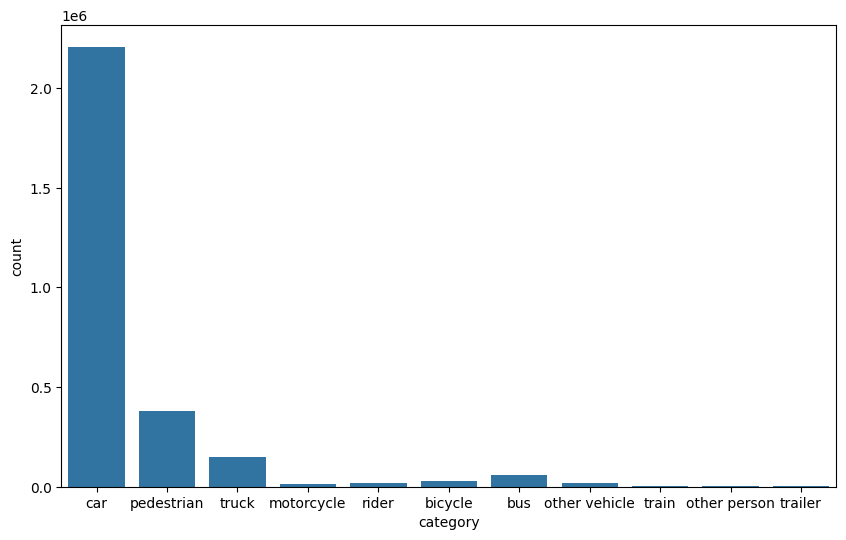

In [ ]:
# Afficher la distribution des category
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category')

Ici on voit que notre dataset est axé sur les voitures ils ont plus d'occurence ce qui est logique car dans la plupart des accidents c'est entre vehicules. De plus on a des classes qui sont faiblement representées donc on trouvera normal que la detection de ces objet soit un peu difficile pour le model.

In [ ]:
# Affichage de quelque images
import random
import itertools
num_samples = 9
image_files = list(itertools.islice(os.scandir(IMG_PATH), 50))
image_files = [f.name for f in image_files if f.is_file()]


rand_images = random.sample(image_files, num_samples)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for i in range(num_samples):
    image = rand_images[i]
    ax = axes[i // 3, i % 3]
    ax.imshow(plt.imread(os.path.join(IMG_PATH, image)))
    ax.set_title(f'Image {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()


Donc ici on peut nous meme visualiser et voir que les situation sont en ville raison pour laquelle il y'a plus d'objet car c'est là qu'il y a plus d'activités dû au nombre de personnes.

Entraînement des données

In [ ]:
class_map

{'cycle': 0, 'heavy_vehicle': 1, 'human': 2, 'vehicle': 3}

Encodage : classification, numéroté les catégories.

In [ ]:
if not os.path.exists('/content/data/images/train'):
    print("⚠️ Attention : Le dossier /content/data/images/train n'existe pas localement.")
    print("Assure-toi d'avoir exécuté l'extraction run_pipeline() avant l'entraînement.")

In [ ]:
#%%writefile data.yaml
import yaml

# Inversion du dictionnaire : Nom -> Index devient Index -> Nom
names_yolo = {i: cls for cls, i in class_map.items()}

config = {
    'path': Local_data_path,
    'train': 'images/train',
    'val': 'images/test',
    'nc': len(classes_list),
    'names': names_yolo
}

# Création du fichier .yaml
with open('/content/data.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

# Nettoyage profond des caches pour éviter les erreurs de lecture avant le lancer
for cache_file in ['/content/data/labels/train.cache',
                   '/content/data/labels/test.cache']:
    if os.path.exists(cache_file):
          os.remove(cache_file)
          print(f"Cache supprimé : {cache_file}")

print(f"Fichier data.yaml prêt pour l'entraînement avec {len(classes_list)} classes.")
# nom de chaque classes détectées
# names:
  #0: cycle
  #1: heavy_vehicle
  #2: human
  #3: vehicle

Fichier data.yaml prêt pour l'entraînement avec 4 classes.


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00


In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [ ]:
import mlflow

mlflow.set_experiment("Capstone_VideoCap_Detection")

2026/04/15 14:34:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/15 14:34:30 INFO mlflow.store.db.utils: Updating database tables
2026/04/15 14:34:34 INFO mlflow.tracking.fluent: Experiment with name 'Capstone_VideoCap_Detection' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1776263674023, experiment_id='1', last_update_time=1776263674023, lifecycle_stage='active', name='Capstone_VideoCap_Detection', tags={}, trace_location=None, workspace='default'>

In [ ]:
!ls /content/data/images/train | head -n 5

In [ ]:
!ls /content/data/labels/train | head -n 5

In [ ]:
torch.cuda.empty_cache()
gc.collect()

659

In [ ]:
train_images_path = "/content/data/images/train"

if os.path.exists(train_images_path):
    images_list = os.listdir(train_images_path)
    print(f"Nombre total d'images d'entraînement : {len(images_list)}")
    print("10 premières images utilisées :")
    for img in images_list[:10]:
        print(f" - {img}")
else:
    print("Dossier introuvable. Vérifiez le chemin dans votre data.yaml.")

Nombre total d'images d'entraînement : 8311
10 premières images utilisées :
 - aug4_029ae5bb-c8d1a298-0000190.jpg
 - aug2_029ad1d1-8c9b02b1-0000001.jpg
 - aug1_029ad1d1-8c9b02b1-0000162.jpg
 - aug1_029e1042-d985bee1-0000177.jpg
 - aug2_029aad77-628b9c45-0000091.jpg
 - aug1_029e1042-d985bee1-0000124.jpg
 - aug4_029ce269-29702a45-0000130.jpg
 - aug0_02b12643-452a1808-0000187.jpg
 - aug0_029ad1d1-8c9b02b1-0000012.jpg
 - aug1_029e1042-d985bee1-0000080.jpg


In [ ]:
# On vérifie un fichier au hasard (modifie le nom si nécessaire)
label_path = '/content/data/labels/train/'
files = os.listdir(label_path)
test_file = os.path.join(label_path, files[0])

print(f"--- Analyse du fichier : {files[0]} ---")
with open(test_file, 'r') as f:
    for line in f:
        print(line.strip())

--- Analyse du fichier : aug3_029e1042-2639a5f8-0000157.txt ---
3 0.041446 0.437716 0.056729 0.052125
3 0.074591 0.437716 0.032507 0.043060
3 0.012601 0.435041 0.025202 0.046596
3 0.439183 0.400322 0.015935 0.024929
3 0.483164 0.393523 0.019759 0.022663
3 0.507066 0.387858 0.016572 0.020397
2 0.450975 0.399189 0.030595 0.095185
2 0.213544 0.425252 0.015935 0.074788
2 0.349947 0.413920 0.013385 0.045326
2 0.399346 0.404855 0.011473 0.040794
3 0.720276 0.371427 0.019759 0.026063
3 0.635821 0.385025 0.038244 0.060057
3 0.643788 0.388991 0.035057 0.047592
3 0.687769 0.402589 0.072026 0.088386
3 0.789434 0.437716 0.133854 0.194903
2 0.761476 0.350726 0.009513 0.016912
3 0.519219 0.388554 0.011977 0.012328
3 0.470142 0.395390 0.010333 0.022850
3 0.462707 0.399198 0.009073 0.017025
3 0.086884 0.433325 0.038936 0.037481
3 0.106391 0.431457 0.040244 0.037635
3 0.134817 0.427100 0.044886 0.042764
3 0.160215 0.428397 0.012236 0.027625
1 0.328255 0.395838 0.040575 0.025538
3 0.362907 0.397406 0.01

In [ ]:
!cat /content/data.yaml
print("\n--- VERIFICATION DES CHEMINS ---")
with open('/content/data.yaml', 'r') as f:
    import yaml
    config = yaml.safe_load(f)
    for key in ['train', 'val']:
        path = os.path.join('/content/data', config[key]) if not config[key].startswith('/') else config[key]
        exists = os.path.exists(path)
        print(f"Le dossier {key} ({path}) existe ? {'✅' if exists else '❌'}")

names:
  0: cycle
  1: heavy_vehicle
  2: human
  3: vehicle
nc: 4
path: /content/data
train: images/train
val: images/test

--- VERIFICATION DES CHEMINS ---
Le dossier train (/content/data/images/train) existe ? ✅
Le dossier val (/content/data/images/test) existe ? ✅


In [ ]:
nb_img=len(os.listdir('/content/data/images/train'))
nb_lab=len(os.listdir('/content/data/labels/train'))
print(f"Ratio images/labels : {nb_img}/{nb_lab}")

Ratio images/labels : 8311/8311


In [ ]:
from ultralytics import YOLO, settings
settings.update({"mlflow": False})

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#label_path = "/content/data/labels/train"
#sample_file = os.path.join(label_path, os.listdir(label_path)[0])

#with open(sample_file, 'r') as f:
    #lines = f.readlines()
    #for line in lines[:3]: # On regarde les 3 premières lignes
        #parts = list(map(float, line.split()))
        #class_id = int(parts[0])
        #coords = parts[1:]
       # print(f"Fichier: {os.path.basename(sample_file)} | Classe: {class_id} | Coords: {coords}")

      #  if any(c > 1.0 for c in coords):
     #       print("❌ ALERTE : Coordonnées non normalisées détectées (> 1.0) !")
   #     else:
    #        print("✅ Coordonnées OK (< 1.0)")

In [ ]:
model = YOLO("yolov8n.pt")  # premier modèle léger (version 8)

with mlflow.start_run(run_name="YOLOv8n_Baseline_Curation"):

    model.train(
        data="/content/data.yaml",
        epochs=50,
        imgsz=640,
        batch=16,
        workers=8,
        cache='disk',
        verbose = True,
        device=0, #Force l'utilisation de GPU Tesla T4
        optimizer='AdamW',
        patience=20,
        seed=42,
        cls=2.0,
        copy_paste=0.6,
        mixup=0.1,
        save_period=5,
        project="Capstone_Video",
        name="Run_A_final"
    )

    #Validation
    results = model.val()

    #Log manuel
    mlflow.log_metric("mAP50", results.box.map50)
    mlflow.log_metric("Precision", results.box.mp)
    mlflow.log_metric("Recall", results.box.mr)

    #Log de l'ARTEFACT
    confusion_matrix_path = f"Capstone_Video/Run_A_final/confusion_matrix.png"
    mlflow.log_artifact(confusion_matrix_path)

print("Succès")

In [ ]:
torch.cuda.empty_cache()
gc.collect()

91

## Évaluation
Le modèle baseline souffrait d'un déséquilibre massif. Grâce à la curation effectuée pour la synchronisation des labels et des images et du déséquilibre des données, nous avons forcées le modèle à voir d'avantage de classes rares. Lorsqu'on a réentraîné le modèle baseline, nous avons pu obtenir un meilleur résultat. Il y a eu plus d'instances pour les classes rares entraînées dans le modèle. Ce qui bloque : manque d'images (n'utilise que 2045 images) limite sa capacitée à voir d'autre classes que 'car'. Ce qui marche : La capacité du modèle à identifier les objets de chaque images, la pipeline est reproductible et robustre.
La prochaine étape : Entraîné le prochain modèle (modèle B = yolo11n), si on peut faire un troisième modèle C.

In [ ]:
model2 = YOLO("yolo11n.pt") # Dernière version de YOLO

# Sécurité : On ferme tout run qui aurait pu rester ouvert après le crash
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="YOLO11n_Curation_v2_Balanced"):

    #On logue un paramètre manuellement pour tester
    mlflow.log_param("optimizer", "AdamW")
    model2.train(
          data="/content/data.yaml",
          epochs=50,
          imgsz=960,
          batch=8,
          workers=8,
          verbose=True,
          cache='disk',
          device=0,
          seed=42,
          patience=20, # optimisation
          optimizer='AdamW',
          cls=2.0,
          copy_paste=0.6,
          mixup=0.1,
          save_period=5,
          project="Capstone_Video",
          name="Run_B_final_Restart",
          exist_ok=True,
          lr0=0.0001,
          cos_lr=True
  )

    #Validation
    results2 = model2.val()

    #Log manuel
    mlflow.log_metric("mAP50", results2.box.map50)
    mlflow.log_metric("Precision", results2.box.mp)
    mlflow.log_metric("Recall", results2.box.mr)

    #Log de l'ARTEFACT
    confusion_matrix_path2 = "runs/detect/Capstone_Video/Run_B_final_Restart/confusion_matrix.png"
    #Vérifie si le fichier existe avant de logguer
    if os.path.exists(confusion_matrix_path2):
        mlflow.log_artifact(confusion_matrix_path2)
        print("Matrice de confusion envoyée à MLflow")
    else:
        print(f"Fichier introuvable dans  : {confusion_matrix_path2}")

print("Succès")

In [ ]:
metrics2 = model2.val(data="/content/data.yaml")

map50 = metrics2.box.map50
precision = metrics2.box.mp
recall = metrics2.box.mr

print(f"Rapport de performance (modèle B)")
print(f"map50 : {map50:.3f}")
print(f"précision : {precision:.3f}")
print(f"Rappel : {recall:.3f}")

In [ ]:
# Le chemin vers le dossier de ton Run B
path = "/content/runs/detect/Capstone_Video/Run_B_final_Restart/train_batch0.jpg"

if os.path.exists(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Image introuvable. Vérifie le chemin !")

In [ ]:
torch.cuda.empty_cache()
gc.collect()

61

In [ ]:
save_path="/content/drive/MyDrive/Capstone_Final_Runs"
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [ ]:
# 1. On force le ramasse-miettes (Garbage Collector) de Python
gc.collect()

# 2. On vide le cache de la mémoire GPU (VRAM)
torch.cuda.empty_cache()

# 3. Diagnostic rapide pour confirmer l'espace libre
if torch.cuda.is_available():
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f"✅ VRAM Nettoyée !")
    print(f"Mémoire disponible : {free_mem / 1024**3:.2f} Go / {total_mem / 1024**3:.2f} Go")
else:
    print("❌ Aucun GPU détecté. Vérifie tes paramètres d'exécution.")

✅ VRAM Nettoyée !
Mémoire disponible : 14.46 Go / 14.56 Go


In [ ]:
!rm -f /content/data/labels/train.cache /content/data/labels/test.cache
#!rm -f /content/data/images/train/* /content/data/images/test/*
print("Caches supprimés")

Caches supprimés


In [ ]:
train_path = "/content/data/images/train"
if os.path.exists(train_path):
    nb_images = len(os.listdir(train_path))
    print(f"Confirmation : {nb_images} images trouvées dans le dossier train.")
else:
    print("Erreur : Le dossier est toujours vide !")

Confirmation : 8311 images trouvées dans le dossier train.


In [ ]:
from tqdm import tqdm

# Chemins basés sur vos logs d'erreur
input_dir = '/content/data/images/train/'

print(f"Début de la conversion dans {input_dir}...")

files = [f for f in os.listdir(input_dir) if f.endswith('.npy')]

for file_name in tqdm(files):
    file_path = os.path.join(input_dir, file_name)
    try:
        # Charger le tableau NumPy
        data = np.load(file_path)

        # Conversion en image (on suppose que c'est du RGB ou Grayscale)
        if data.dtype != np.uint8:
            data = (data * 255).astype(np.uint8) if data.max() <= 1.1 else data.astype(np.uint8)

        img = Image.fromarray(data)

        # Sauvegarder en .jpg au même endroit
        img.save(file_path.replace('.npy', '.jpg'))

        # IMPORTANT : Supprimer le fichier .npy pour que YOLO ne le lise plus
        os.remove(file_path)

    except Exception as e:
        print(f"Erreur sur {file_name}: {e}")

print("Conversion terminée et fichiers .npy nettoyés ! ✅")

Début de la conversion dans /content/data/images/train/...


0it [00:00, ?it/s]

Conversion terminée et fichiers .npy nettoyés ! ✅


In [ ]:
print("Vérification de l'intégrité des images...")
bad_images = 0
for folder in ['train', 'test']:
    path = f'/content/data/images/{folder}'
    for img_name in os.listdir(path):
        try:
            with Image.open(os.path.join(path, img_name)) as i:
                w, h = i.size
                if w <= 1 or h <= 1:
                    print(f"❌ Image trop petite/invalide : {img_name} ({w}x{h})")
                    bad_images += 1
        except Exception as e:
            print(f"❌ Fichier corrompu : {img_name} - Error: {e}")
            bad_images += 1

if bad_images == 0:
    print("✅ Toutes les images sont valides. Le problème vient des paramètres YOLO.")
else:
    print(f"⚠️ {bad_images} images problématiques détectées.")

Vérification de l'intégrité des images...
✅ Toutes les images sont valides. Le problème vient des paramètres YOLO.


In [ ]:
labels_train_path = '/content/data/labels/train'

if os.path.exists(labels_train_path):
    nb_labels = len([f for f in os.listdir(labels_train_path) if f.endswith('.txt')])
    print(f"✅ {nb_labels} fichiers de labels (.txt) trouvés dans {labels_train_path}")

    if nb_labels > 0:
        # Vérifier le contenu du premier fichier pour le format
        sample_file = os.path.join(labels_train_path, os.listdir(labels_train_path)[0])
        with open(sample_file, 'r') as f:
            print(f"Exemple de contenu ({os.path.basename(sample_file)}) : {f.readline().strip()}")
else:
    print(f"❌ Dossier de labels introuvable ! YOLO s'attend à le trouver ici : {labels_train_path}")

✅ 8311 fichiers de labels (.txt) trouvés dans /content/data/labels/train
Exemple de contenu (aug3_02a26ce5-597cae3f-0000084.txt) : 3 0.381818 0.579573 0.037942 0.049771


In [ ]:
print(len(os.listdir('/content/data/labels/test')))

In [ ]:
!rm -rf /content/data/images/train/.ipynb_checkpoints
!rm -rf /content/data/labels/train/.ipynb_checkpoints

In [ ]:
print(len(os.listdir('/content/data/images/test')))

In [ ]:
from collections import Counter

test_img_path = '/content/data/images/test'
extensions = [os.path.splitext(f)[1] for f in os.listdir(test_img_path)]
print("Répartition des extensions dans TEST :", Counter(extensions))

Répartition des extensions dans TEST : Counter({'.jpg': 220})


In [ ]:
def check_sync(mode):
    img_path = f'/content/data/images/{mode}'
    lab_path = f'/content/data/labels/{mode}'

    imgs = {os.path.splitext(f)[0] for f in os.listdir(img_path) if f.endswith('.jpg')}
    labs = {os.path.splitext(f)[0] for f in os.listdir(lab_path) if f.endswith('.txt')}

    print(f"--- Rapport {mode.upper()} ---")
    print(f"Images JPG : {len(imgs)}")
    print(f"Labels TXT : {len(labs)}")

    if imgs == labs:
        print("✅ Synchronisation parfaite !")
    else:
        print(f"❌ Erreur : {len(imgs - labs)} images sans labels ou {len(labs - imgs)} labels sans images.")

check_sync('train')
check_sync('test')

--- Rapport TRAIN ---
Images JPG : 8311
Labels TXT : 8311
✅ Synchronisation parfaite !
--- Rapport TEST ---
Images JPG : 220
Labels TXT : 220
✅ Synchronisation parfaite !


In [ ]:
import os
from collections import Counter

path = '/content/data/images/train/'
files = os.listdir(path)

# On extrait le préfixe (ex: aug0, aug1, ou original)
prefixes = [f.split('_')[0] if f.startswith('aug') else 'original' for f in files if f.endswith('.jpg')]

print("--- Décompte des fichiers par génération ---")
for prefix, count in sorted(Counter(prefixes).items()):
    print(f"Génération {prefix} : {count} images")

print(f"\nTotal général : {len(prefixes)} images JPG.")

--- Décompte des fichiers par génération ---
Génération aug0 : 1621 images
Génération aug1 : 1621 images
Génération aug2 : 1621 images
Génération aug3 : 1621 images
Génération aug4 : 1621 images
Génération original : 206 images

Total général : 8311 images JPG.


In [ ]:
# Supprimer tous les fichiers .npy du dossier images pour éviter les erreurs YOLO
!find /content/data/images/train -name "*.npy" -type f -delete
!find /content/data/images/test -name "*.npy" -type f -delete

print("Nettoyage terminé : seuls les fichiers images (.jpg) ont été conservés.")

Nettoyage terminé : seuls les fichiers images (.jpg) ont été conservés.


In [ ]:
settings.update({"mlflow": False})

# Sécurité : On ferme tout run qui aurait pu rester ouvert après le crash
if mlflow.active_run():
    mlflow.end_run()

project_name = "/content/drive/MyDrive/Capstone_Final_Runs"
run_name = "Run_C_V8_Rescue"

with mlflow.start_run(run_name=run_name):
    #Du modèle 'Nano' au modèle 'Medium'
    model3 = YOLO("yolo11m.pt") # Dernière version de YOLO

    mlflow.log_param("optimizer", "AdamW")
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("model_Variant", "Medium")

    model3.train(
        data="/content/data.yaml",
        epochs=100,
        imgsz=640,
        batch=8,
        workers=2,
        verbose=True,
        cache='disk',
        device=0,
        seed=42,
        patience=50, # optimisation
        optimizer='AdamW',
        project=project_name,
        name=run_name,
        exist_ok=True,
        amp=True,
        cls=2.5,
        freeze=10,
        lr0=0.001, #Apprentissage plus fin pour stabiliser le mAP
        lrf=0.01,
        cos_lr=True,
        mosaic=1.0,
        dfl=1.5,
        close_mosaic=20, # Finition sur images réelles
        copy_paste=0.6, # Force le modèle à voir plus de classe rares
        mixup=0.4, # Aide la généralisation
        save_period=5,
        auto_augment='randaugment',
        multi_scale=False,
        degrees=10.0, # Rotation pour gérer les virages/vibrations
        scale=0.7,  # Gestion de la profondeur
        box=7.5, # Priorité à la précision de la localisation
        fliplr=0.5, # Symétrie ho
        warmup_epochs=5.0,
        iou=0.7,  # Rigueur de localisation
        hsv_v=0.4,
        label_smoothing=0.1,
        pretrained=True # S'assurer d'utiliser les poids COCO comme base
    )

    #Validation
    results3 = model3.val(augment=True)

    #Log manuel
    mlflow.log_metric("mAP50", results3.box.map50)
    mlflow.log_metric("Precision", results3.box.mp)
    mlflow.log_metric("Recall", results3.box.mr)

    #Log de l'ARTEFACT
    save_dir = model3.trainer.save_dir
    conf_path = os.path.join(save_dir, "confusion_matrix.png")
    results_path = os.path.join(save_dir, "results.png")
    #Vérifie si le fichier existe avant de logguer
    if os.path.exists(conf_path):
        mlflow.log_artifact(conf_path)
        print("Matrice de confusion envoyée à MLflow.")
    else:
        print(f"Fichier confusion_matrix.png introuvable dans  : {save_dir}")

    if os.path.exists(results_path):
        mlflow.log_artifact(results_path)
        print(f"Courbes de résultats (results.png) envoyées à MLflow")
    else:
        print(f"Fichier results.png introuvable dans  : {save_dir}")

print("Succès")

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=20, cls=2.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.6, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.4, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=Run_C_V8_Rescue, nbs=64, nms=False, ops

Cellule de reprise de l'entraînement dû au limite GPU dans le dossier 'Capstone_Final_Runs'.

In [ ]:
!find /content/data/images -name "*.npy" -type f -delete
print("Nettoyage validé. Seuls les .jpg restent.")

Nettoyage validé. Seuls les .jpg restent.


In [ ]:
# Sécurité : On ferme tout run qui aurait pu rester ouvert après le crash
if mlflow.active_run():
    mlflow.end_run()

def resume_train_v8():
    path = "/content/drive/MyDrive/Capstone_Final_Runs/Run_C_V8_Rescue/weights/last.pt"

    # 1. Vérifier si le Drive est bien monté
    if not os.path.exists("/content/drive/MyDrive"):
        print("❌ Erreur : Le Google Drive n'est pas monté.")
        return

    # 2. Vérifier si les données locales sont prêtes
    if not os.path.exists("/content/data/images/train"):
        print("⚠️ Attention : Le dossier /content/data/ est vide !")
        print("Relance tes cellules de préparation de données (Oversampling/Symlinks) avant de reprendre.")
        return

    if os.path.exists(path):
        print(f"✅ Reprise du run 'V8_Rescue' depuis l'époque sauvegardée : {path}")
        model = YOLO(path)
        # On ne passe aucun autre argument, resume=True suffit
        model.train(
            resume=True
        )
    else:
        print(f"❌ Fichier last.pt introuvable à l'adresse : {path}")

resume_train_v8()

✅ Reprise du run 'V8_Rescue' depuis l'époque sauvegardée : /content/drive/MyDrive/Capstone_Final_Runs/Run_C_V8_Rescue/weights/last.pt
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=20, cls=2.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.6, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.4, mode=train, model=/content/drive/MyDrive/Capstone_Final_Runs/Run_

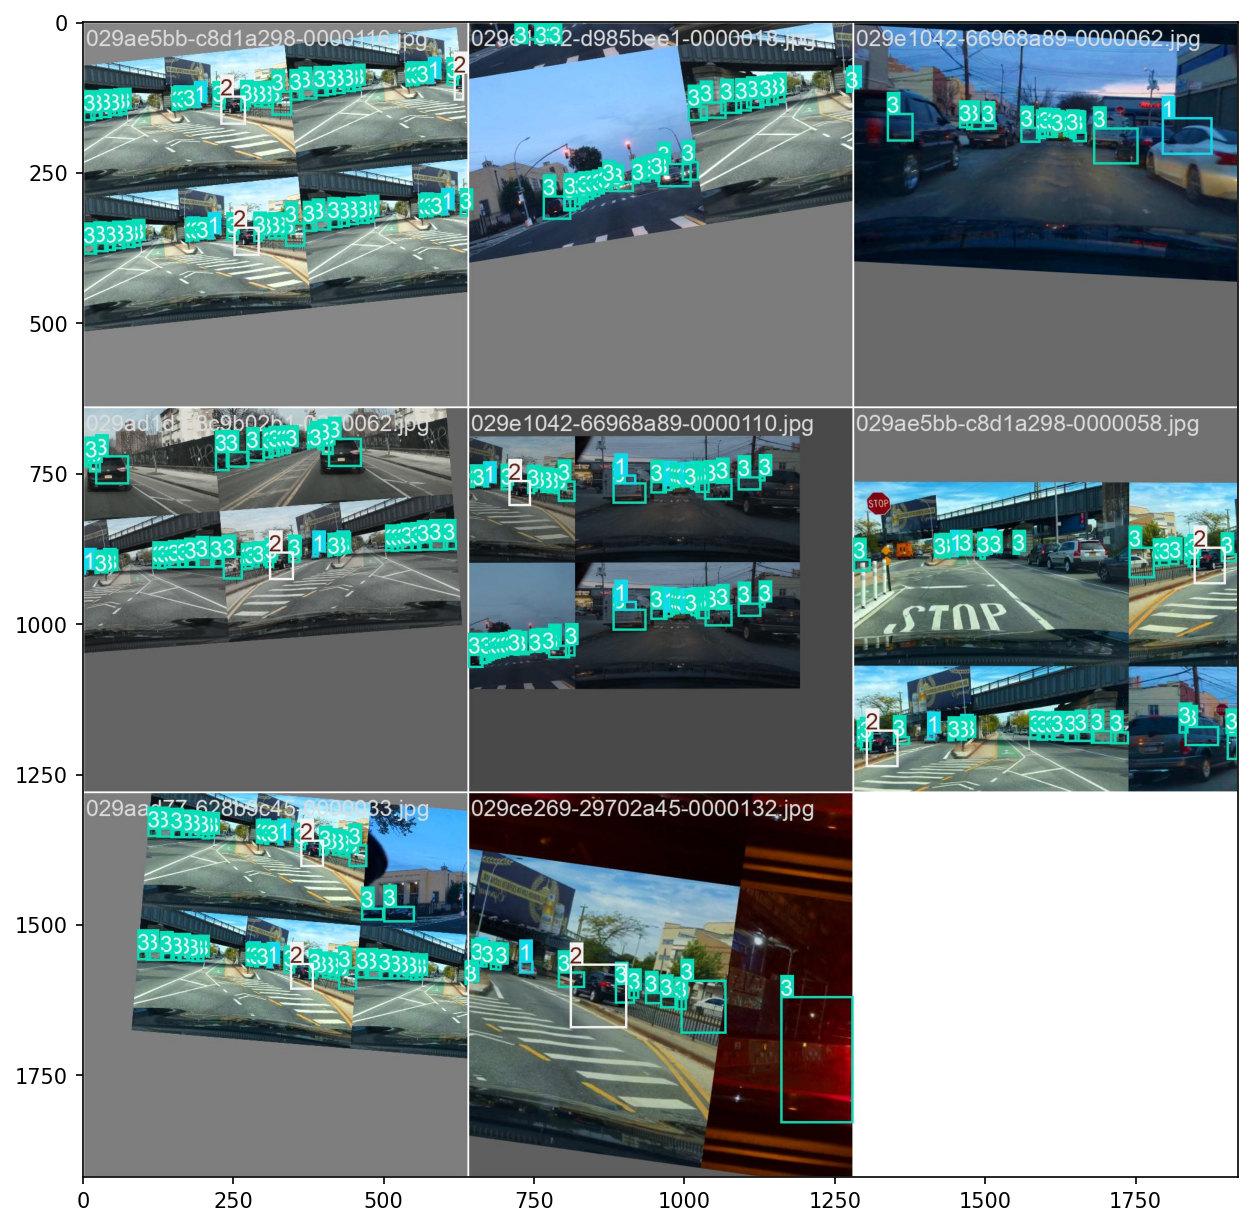

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Affiche une image d'entraînement avec ses labels
img_path = "/content/drive/MyDrive/Capstone_Final_Runs/Run_C_V6_Full_Learning_correction/train_batch0.jpg"
if os.path.exists(img_path):
    img = cv2.imread(img_path)
    plt.rcParams['figure.dpi'] = 150
    plt.figure(figsize=(15,10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

In [ ]:
#import glob

#model_final = YOLO("yolo11s.pt")

# Le reste de ton code de validation...
#model_final.val(data="/content/data.yaml", plots=True, imgsz=640, batch=1)
# On utilise l'outil interne d'Ultralytics pour dessiner un batch de test


# Affichage de l'image générée
#path_val_plot = "runs/detect/val/val_batch0_labels.jpg"
#if os.path.exists(path_val_plot):
   # img = cv2.imread(path_val_plot)
 #   img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  #  plt.figure(figsize=(20, 20))
   # plt.imshow(img)
    #plt.axis('off')
    #plt.title("Vérification visuelle : Les boîtes doivent être BIEN centrées sur les objets")
    #plt.show()
#else:
 #   print("⚠️ Plot non généré. Vérifie si model.val() a bien tourné.")

In [ ]:
#results_v8 = pd.read_csv('/content/runs/detect/train/results.csv')
#results_v11 = pd.read_csv('/content/runs/detect/train2/results.csv')
#results_v11_2 = pd.read_csv('/content/runs/detect/.../results.csv')

#plt.figure(figsize=(10,5))
#plt.plot(results_v8['epoch'], results_v8['train/box_loss'], label='YOLOv8 (Baseline)')
#plt.plot(results_v11['epoch'], results_v11['train/box_loss'], label='YOLOv11 (Amélioré)')
#plt.plot(results_v11_2['epoch'], results_v11_2['train/box_loss'], label='YOLOv11 (Amélioré + Curation)')

#plt.title("Comparaison de la convergence (Box Loss)")
#plt.xlabel('Époques')
#plt.ylabel('Loss')
#plt.legend()
#plt.grid(True)
#plt.show()

In [ ]:
#Lancement du serveur MLflow
import subprocess
import threading
import time

!pkill -f cloudflared
!pkill -f mlflow

if os.path.exists('tunnel.log'): os.remove('tunnel.log')

# Lancement de MLflow en arrière-plan
print("Lancement du serveur MLflow...")
subprocess.Popen(['mlflow', 'ui', '--host', '127.0.0.1', '--port', '5000'])
time.sleep(8)

#Installation de Cloudflared (le tunnel ultra-stable)
print("Configuration du tunnel sécurisé...")
if not os.path.exists('/usr/local/bin/cloudflared'):
    !wget https://github.com/Cloudflare/Cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
    !dpkg -i cloudflared-linux-amd64.deb

def start_tunnel():
    os.system('cloudflared tunnel --url http://127.0.0.1:5000 --http-host-header 127.0.0.1:5000 > tunnel.log 2>&1')
#!npm install -g localtunnel

threading.Thread(target=start_tunnel, daemon=True).start()

print("="*60)
print("Attendez 10 secondes, puis cherchez le lien '.trycloudflare.com' ci-dessous :")
print("="*60)

In [ ]:
print("Recherche du lien actif dans tunnel.log")

time.sleep(2)
if os.path.exists('tunnel.log'):
    !grep -o 'https://.*\.trycloudflare.com' tunnel.log | tail -n 1 || echo "Lien non trouvé, attends encore 5 et relance cette cellule"
else:
    print("Fichier tunnel.log introuvable. Relance la Cellule précédante.")

In [ ]:
if os.path.exists('tunnel.log'):
    !cat tunnel.log
else:
    print("Le fichier log n'Est pas encore créé. Relance la Cellule 1")

In [ ]:
mlflow.set_tracking_uri("file:///content/mlruns")

exp_name = "Capstone_VideoCap_Detection"
mlflow.set_experiment(exp_name)

with mlflow.start_run(run_name="Run_C_Imported"):
    path_run_c = "/content/runs/detect/Capstone_Video/Run_C_Final_Small"

    if os.path.exists(path_run_c):
        mlflow.log_artifacts(path_run_c)
        print("Run C importé ! Rafraîchis ton interface MLflow.")
    else:
        print(f"Chemin introuvable. Vérifie l'orthographe du dossier. {path_run_c}")

In [ ]:
import json

final_weights = ("/content/drive/MyDrive/Capstone_Final_Runs/Run_C_V8_Final/weights/best.pt")
final_model = YOLO(final_weights)

#best_model_source = os.path.join(model3.trainer.save_dir, 'weights/best.pt')

print("Lancement de la validation finale pour le rapport")

results_final = final_model.val()

export_path = f"{Drive_path}/Export_Modele_Final"
os.makedirs(export_path, exist_ok=True)

config = {
    "model_name": "YOLOv11s_VideoCap_Video",
    "version": "1.1",
    "classes": final_model.names,
    "imgsz": 640,
    "metrics": {
        "mAP50": float(results_final.box.map50),
        "Recall": float(results_final.box.mr),
        "Precision": float(results_final.box.mp)
    },
    #"normalisation": "YOLO Standard (0-1)"
    "date_export": "2026-03-31"
}
with open(f"{export_path}/pipeline_config.json", "w") as f:
    json.dump(config, f, indent=4)

# Copie le meilleur modèle trouvé.
if os.path.exists(final_weights):
    shutil.copy(final_weights, f"{export_path}/best_model_v11s.pt")
    print(f"Pipeline et modèle sauvegardés dans {export_path}")
else:
    print(f"Fichier introuvable : {final_weights}")

Lancement de la validation finale pour le rapport
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 32.2±6.1 MB/s, size: 221.0 KB)
val: Scanning /content/data/labels/test.cache... 220 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 43.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 3.2it/s 4.4s
                   all        220       1831    0.00739     0.0141     0.0046    0.00157
                 cycle         62         78          0          0          0          0
         heavy_vehicle         81        125          0          0    8.1e-05   2.43e-05
                 human         74        138          0          0   0.000476   0.000115
               vehicle        220       1490     0.0296     0.0564     0.0178    0.00613
Sp

| Métrique | YOLOv8n(Baseline) | YOLO11n(Amélioré) | YOLO11s(Amélioré + Curation) |
|-------------|-------------------|---------|-------------------|
| MAP50    |  0.015    |  0.027  |     0.0056     |
| Précision |   0.007 | 0.048  | 0.255 |
| Rappel | 0.062 | 0.00854  |  0.0441 |
| Temps d'Entraînement | ~35m   |    ~32m     | ~ 1h15 (pour 40 époques)|
| Résultat | Le modèle n'est pas fiable. |   Il est plus fiable. Moins de faux positifs |  Modèle le plus sélectif.  |
| Commentaire | Il s'est arrêté la 49 epochs. On n'utilise que 1856 images. | Il diserne mieux les vrais/faux images. | Curation totale (195 cycles). Augmentations fortes.|


#Conclusion

Le modèle final que nous utiliserons pour le déployment sera le YOLO11s. Il est plus efficace, dans ce context. Les images ont la taille de 940 pour que le modèle ait une meilleur visibilité sur les instances. Distingue mieux les classes rares que les deux derniers modèles. Le temps d'entraînement est plus long (100 epochs, 30 patience). En dépit des limites de GPU, on a pu entrainé le modèle. Le modèle 'YOLO11s' 'small' a plus de paramètres ce qui est idéal pour mieux distinguer les classes. Avec la fusion des classes, le GPU devrait s'epuisser moins vite. On force le modèle apprendre les classes rares et en augmentant la résolution de l'image, le modèle a une meilleure visibilité.